Libraries

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import numpy as np
import nltk
import re

In [2]:
nltk.download("stopwords")
default_stopwords = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Load files

In [3]:
base_path = Path("/kaggle/input/datasets/aminaghandouz/textbrats20/TextBraTSData")
folders = sorted(base_path.glob("BraTS20_Training_*"))

In [4]:
txt_data = []
for folder in tqdm(folders, desc="Processing folders"):
    txt_files = list(folder.glob("*.txt"))
    
    for txt_file in txt_files:
        content = txt_file.read_text(encoding="utf-8")
        
        txt_data.append({
            "folder": folder.name,
            "file": txt_file.name,
            "content": content
        })

Processing folders: 100%|██████████| 369/369 [00:05<00:00, 73.17it/s]


In [5]:
len(txt_data)

369

In [6]:
txt_data[0]

{'folder': 'BraTS20_Training_001',
 'file': 'BraTS20_Training_001_flair_text.txt',
 'content': 'The lesion area is in the right frontal and parietal lobes with a mixed pattern of high and low signals with speckled high signal regions. Edema is mainly observed in the right parietal lobe, partially extending to the frontal lobe, presenting as high signal, indicating significant tissue swelling around the lesion. Necrosis is within the lesions of the right parietal and frontal lobes, appearing as mixed, with alternating high and low signal regions. Ventricular compression is seen in the lateral ventricles with significant compressive effects on the brain tissue and ventricles.'}

Text Cleaning

In [7]:
def clean_text(text, remove_stopwords=False):
    text = text.lower()
    text = re.sub(r"[^\w\s\.\-\+]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if remove_stopwords:
        tokens = text.split()
        tokens = [t for t in tokens if t not in default_stopwords]
        text = " ".join(tokens)
    
    return text

In [8]:
for item in txt_data:
    item["cleaned"] = clean_text(item["content"], remove_stopwords=True)

Keyword frequency

In [11]:
def get_top_ngrams(texts, n=1, top_k=20):
    counter = Counter()
    for text in texts:
        tokens = text.split()
        ngrams = zip(*[tokens[i:] for i in range(n)])
        ngrams = [" ".join(ng) for ng in ngrams]
        counter.update(ngrams)
    return counter.most_common(top_k)

texts = [item["cleaned"] for item in txt_data]

In [12]:
print("top unigrams:", get_top_ngrams(texts, n=1))

top unigrams: [('high', 759), ('parietal', 751), ('signal', 748), ('left', 736), ('frontal', 679), ('right', 675), ('lesion', 673), ('lobe', 585), ('area', 560), ('low', 521), ('compression', 476), ('lobes', 471), ('edema', 467), ('signals', 451), ('ventricular', 417), ('necrosis', 408), ('areas', 399), ('mixed', 359), ('temporal', 341), ('significant', 332)]


In [13]:
print("top bigrams:", get_top_ngrams(texts, n=2))


top bigrams: [('lesion area', 431), ('ventricular compression', 370), ('high signal', 322), ('high low', 284), ('frontal parietal', 240), ('right frontal', 233), ('parietal lobe', 222), ('low signals', 219), ('parietal lobes', 215), ('frontal lobe', 209), ('low signal', 208), ('left frontal', 189), ('signal intensity', 176), ('left parietal', 175), ('area left', 165), ('edema significant', 163), ('area right', 156), ('areas. edema', 137), ('lateral ventricle', 133), ('right parietal', 129)]


In [14]:
print("top trigrams:", get_top_ngrams(texts, n=3))

top trigrams: [('high low signals', 173), ('frontal parietal lobes', 169), ('lesion area left', 156), ('lesion area right', 146), ('ventricular compression observed', 129), ('heterogeneous high low', 102), ('right frontal lobe', 94), ('right frontal parietal', 87), ('left frontal parietal', 84), ('left parietal lobe', 83), ('high signal areas.', 79), ('area right frontal', 77), ('signal areas. edema', 77), ('right parietal lobe', 68), ('left frontal lobe', 66), ('area left frontal', 65), ('left lateral ventricle', 65), ('mixed high low', 65), ('areas. edema significant', 63), ('right lateral ventricle', 62)]


Word clouds

In [16]:
corpus = " ".join(item["cleaned"] for item in txt_data)

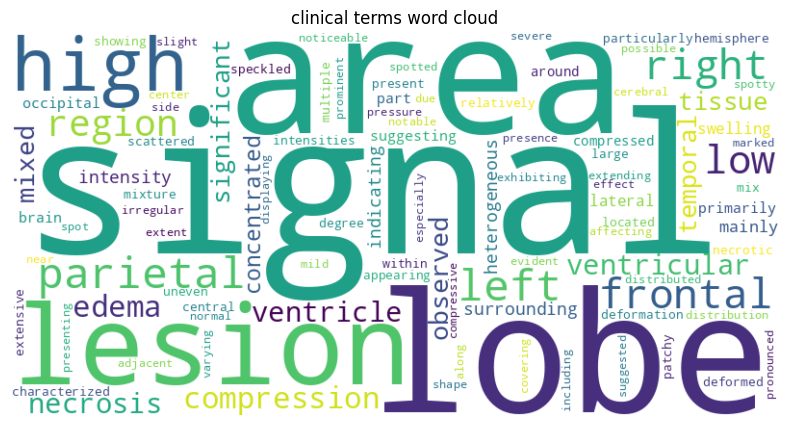

In [17]:
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    collocations=False
).generate(corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("clinical terms word cloud")
plt.show()

Report Length

In [19]:
texts = [item["cleaned"] for item in txt_data]
lengths = [len(t.split()) for t in texts]

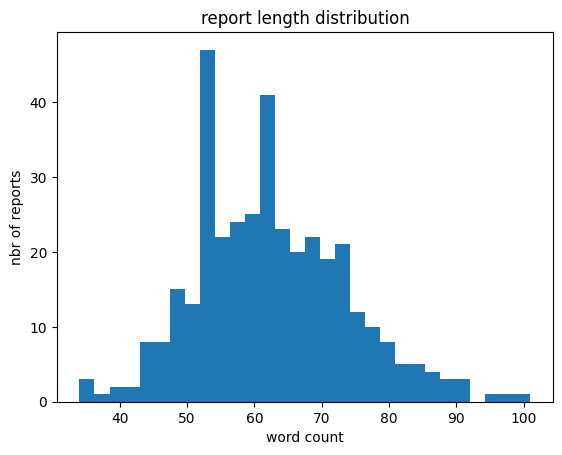

In [23]:
plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("word count")
plt.ylabel("nbr of reports")
plt.title("report length distribution")
plt.show()

Classification (Rule based)

In [28]:
tumor_keywords = {
    "tumor", "mass", "lesion", "neoplasm",
    "enhancement", "enhancing", "heterogeneous",
    "edema", "necrosis", "infiltration",
    "mass effect", "midline shift"
}

non_tumor_keywords = {
    "normal", "no abnormality", "unremarkable",
    "no lesion", "no mass", "no enhancement",
    "without evidence", "intact", "symmetric"
}

In [29]:
def compute_score(text, keywords):
    score = 0
    for kw in keywords:
        if kw in text:
            score += 1
    return score

In [30]:
def has_negation(text, keyword):
    negations = ["no", "not", "without"]
    for neg in negations:
        pattern = f"{neg} {keyword}"
        if pattern in text:
            return True
    return False

In [31]:
def classify_report(text):
    tumor_score = 0
    non_tumor_score = 0
    for kw in tumor_keywords:
        if kw in text:
            if not has_negation(text, kw):
                tumor_score += 1
    for kw in non_tumor_keywords:
        if kw in text:
            non_tumor_score += 1
    if tumor_score > non_tumor_score:
        return "tumor", tumor_score, non_tumor_score
    elif non_tumor_score > tumor_score:
        return "non-tumor", tumor_score, non_tumor_score
    else:
        return "uncertain", tumor_score, non_tumor_score

In [33]:
rule_based_results = []
for item in txt_data:
    label, t_score, nt_score = classify_report(item["cleaned"])
    rule_based_results.append({
        "file": item["file"],
        "label": label,
        "tumor_score": t_score,
        "non_tumor_score": nt_score
    })

In [35]:
labels = [r["label"] for r in rule_based_results]
Counter(labels)

Counter({'tumor': 369})

Classification (Traditional ML)

In [47]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))

In [48]:
X = vectorizer.fit_transform([item["cleaned"] for item in txt_data])

In [49]:
kmeans = KMeans(n_clusters=2, random_state=42)

In [50]:
clusters = kmeans.fit_predict(X)

In [52]:
Counter(clusters)

Counter({np.int32(0): 170, np.int32(1): 199})

In [54]:
terms = vectorizer.get_feature_names_out()
for i in range(2):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[::-1][:10]
    
    print(f"cluster {i}:")
    print([terms[j] for j in top_idx])

cluster 0:
['right', 'signal', 'right frontal', 'high', 'frontal', 'lobe', 'parietal', 'lobes', 'right parietal', 'lesion']
cluster 1:
['left', 'signal', 'high', 'parietal', 'left frontal', 'lobe', 'frontal', 'left parietal', 'lesion', 'areas']
